In [1]:
import numpy as np
import openmc
from pathlib import Path

In [12]:
inner_boundary = np.load("NT_inner_boundary.npy")
outer_boundary = np.load("NT_outer_boundary.npy")
breeder_boundary = np.load("NT_breeder_boundary.npy")

(np.float64(271.7578592021288),
 np.float64(718.3052557324773),
 np.float64(-412.8862927180323),
 np.float64(446.44203311655536))

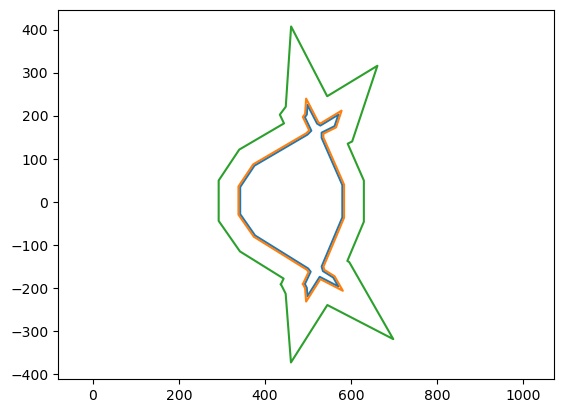

In [13]:
import matplotlib.pyplot as plt
plt.plot(inner_boundary[:,0], inner_boundary[:,1])
plt.plot(outer_boundary[:,0], outer_boundary[:,1])
plt.plot(breeder_boundary[:,0], breeder_boundary[:,1])
plt.axis('equal')

In [14]:
materials_fname = Path("~/ISFNT-15/Materials/materials.xml").expanduser()
materials = openmc.Materials.from_xml(materials_fname)

for mat in materials:
    if mat.name == "tungsten":
        tungsten = mat
    elif mat.name == "breeder":
        breeder_mat = mat

/home/btaczak/.conda/envs/openmc-env/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/home/btaczak/.conda/envs/openmc-env/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)


In [15]:
z_divs = 158.03081447773055
r_hemispheres = 525.0
x_min, x_max = -1000.0, 1000.0
y_min, y_max = -1000.0, 1000.0
z_min, z_max = -1000.0, 1000.0

In [16]:
upper_div_plane = openmc.ZPlane(z0=z_divs)
lower_div_plane = openmc.ZPlane(z0=-z_divs)
r_divider_cylinder = openmc.ZCylinder(r=r_hemispheres)
bounding_box = openmc.model.RectangularParallelepiped(x_min, x_max, y_min, y_max, z_min, z_max, boundary_type = 'vacuum')

In [17]:
nbi_width = 50
nbi_height = 50
nbi_x_location = 0

nbi_duct = openmc.model.RectangularPrism(nbi_width,nbi_height,axis='x',origin=(nbi_x_location,0,0))

In [18]:
inner_wall = openmc.model.Polygon(points=inner_boundary, basis='rz')
outer_wall = openmc.model.Polygon(points=outer_boundary, basis='rz')
breeder_wall = openmc.model.Polygon(points=breeder_boundary, basis='rz')

plasma = -inner_wall  # polygon extruded in Y
upper_div = +inner_wall & -breeder_wall & +upper_div_plane
lower_div = +inner_wall & -breeder_wall & -lower_div_plane
outer_first_wall = +inner_wall & -outer_wall & +lower_div_plane & -upper_div_plane & +r_divider_cylinder
inner_first_wall = +inner_wall & -outer_wall & +lower_div_plane & -upper_div_plane & -r_divider_cylinder

outer_breeder = +outer_wall & -breeder_wall & +lower_div_plane & -upper_div_plane & +r_divider_cylinder
inner_breeder = +outer_wall & -breeder_wall & +lower_div_plane & -upper_div_plane & -r_divider_cylinder
bounding_region = -bounding_box & +breeder_wall

In [19]:
cells = []

plasma = openmc.Cell(name=f"plasma", fill=None, region=plasma)
upper_div_cell = openmc.Cell(name=f"upper_div", fill=tungsten, region=upper_div)
lower_div_cell = openmc.Cell(name=f"lower_div", fill=tungsten, region=lower_div)
outer_first_wall_cell = openmc.Cell(name=f"outer_first_wall", fill=tungsten, region=outer_first_wall)
inner_first_wall_cell = openmc.Cell(name=f"inner_first_wall", fill=tungsten, region=inner_first_wall)
outer_breeder_cell = openmc.Cell(name=f"outer_breeder", fill=breeder_mat, region=outer_breeder)
inner_breeder_cell = openmc.Cell(name=f"inner_breeder", fill=breeder_mat, region=inner_breeder)
bounding_cell = openmc.Cell(name="bounds", fill=None, region=bounding_region)
cells=[plasma, 
    upper_div_cell, 
    lower_div_cell,
    outer_first_wall_cell,
    inner_first_wall_cell,
    outer_breeder_cell,
    inner_breeder_cell,
    bounding_cell]

geometry = openmc.Geometry(openmc.Universe(cells=cells))
geometry.remove_redundant_surfaces()
geometry.export_to_xml()

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

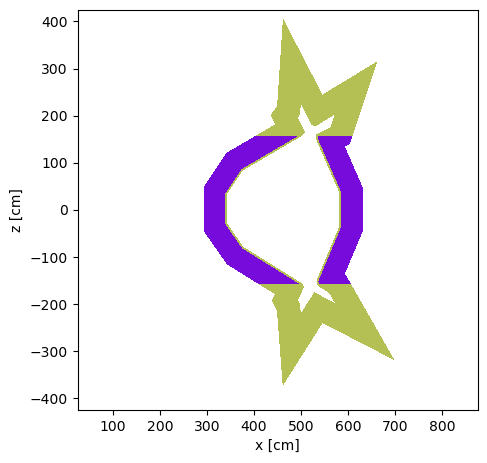

In [22]:
geometry.plot(origin=(450,0,0),width=(850,850),basis='xz',pixels=(400,400),color_by='material')

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

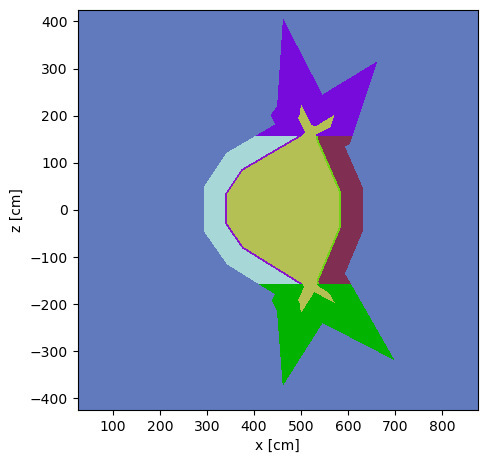

In [23]:
geometry.plot(origin=(450,0,0),width=(850,850),basis='xz',pixels=(400,400))